In [5]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(vals, mu, sigma):
    return np.exp(-(vals - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))


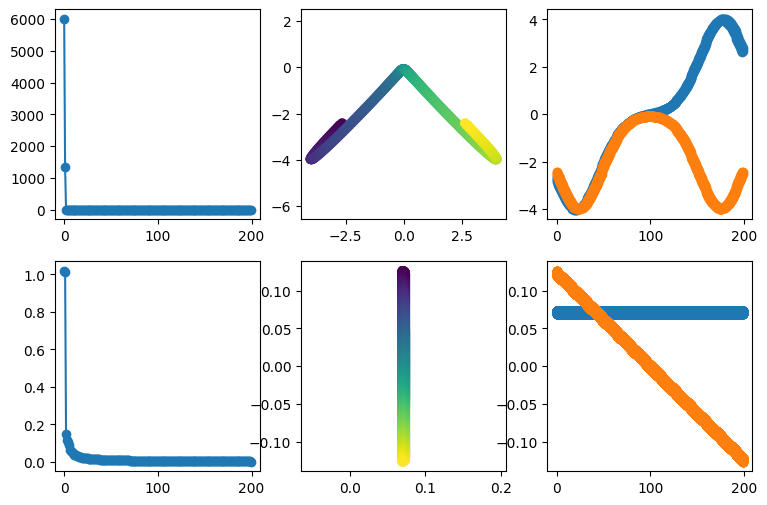

In [6]:
S = 200
A_l = [1, S//2]
fig, axs = plt.subplots(len(A_l), 3, figsize=(9, 3*len(A_l)))
for ind, A in enumerate(A_l):
    sigma = S/A/10

    actions = np.arange(-A, A+1)
    s_obs = np.zeros((S, S))
    for s_curr in range(S):
        for s_val in range(S):
            s_obs[s_curr, s_val] = gaussian(s_val, s_curr, sigma)
    s_obs /= s_obs.max()

    X = []
    y = []
    loc_y = []
    for s in range(S):
        for a in actions:
            s_next = s + a
            if s_next < 0 or s_next > S-1:
                continue
            X.append(np.concatenate([s_obs[s], [a]]))
            y.append(s_obs[s_next])
            loc_y.append(s_next)

    X = np.array(X)
    y = np.array(y)
    loc_y = np.array(loc_y)

    OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
    U, L, V = np.linalg.svd(OLS)
    axs[ind, 0].plot(L, marker='o')\

    axs[ind, 1].scatter(X@U[:,0]*L[0], X@U[:,1]*L[1], c=loc_y)
    axs[ind, 1].axis('equal')

    axs[ind, 2].scatter(loc_y, X@U[:,0]*L[0])
    axs[ind, 2].scatter(loc_y, X@U[:,1]*L[1])


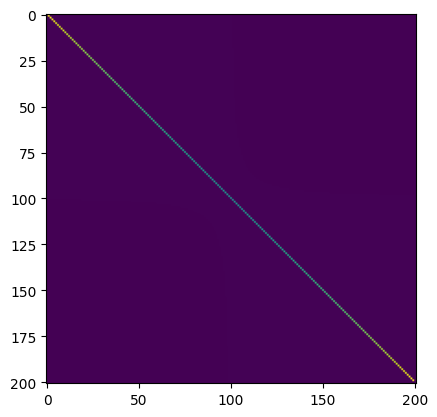

In [7]:
plt.imshow(np.linalg.pinv(X.T@X))